# EDA for Scoring Batting Stats by Team (AVG, RBI, HR)

In [ ]:
#imports
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# The file location
merged_stats = "https://raw.githubusercontent.com/csc442-team11/MLB-Data-Analysis/refs/heads/main/Datasets/mlb-player-stats-Batters-2023-2024-cleaned.csv"


# Read in the file
df_merged = pd.read_csv(merged_stats)

#Team Stats

In [ ]:
# Average and sum team's RBI, HR, and AVG
start_time = time.time()

# New dataframe with sum of desired columns, sorted by team
original_stats = df_merged.groupby("Team")[["RBI", "HR", "AVG"]].sum()
# Find the mean for AVG
original_stats["AVG"] = df_merged.groupby("Team")["AVG"].mean()
# Average team stats
avg_rbi, avg_hr, avg_avg = original_stats["RBI"].mean(), original_stats["HR"].mean(), original_stats["AVG"].mean()


# Only keep teams that have above average batting stats
team_stats = original_stats[(original_stats["RBI"] > avg_rbi) & (original_stats["HR"] > avg_hr) & (original_stats["AVG"] > avg_avg)]

execution_time = time.time() - start_time

print(team_stats.head)
print(f"Rows Returned: {len(team_stats)}")
print(f"Execution Time: {execution_time:.5f} seconds")


<bound method NDFrame.head of        RBI   HR       AVG
Team                     
ARI   1759  448  0.250571
ATL   1991  629  0.247722
BAL   1563  425  0.242939
HOU   1523  418  0.252034
KC    1521  392  0.242515
LAD   1809  515  0.246969
MIN   1375  375  0.245719
PHI   1507  415  0.257778>
Rows Returned: 8
Execution Time: 0.05592 seconds


# Correlation of RBI, HR, and AVG

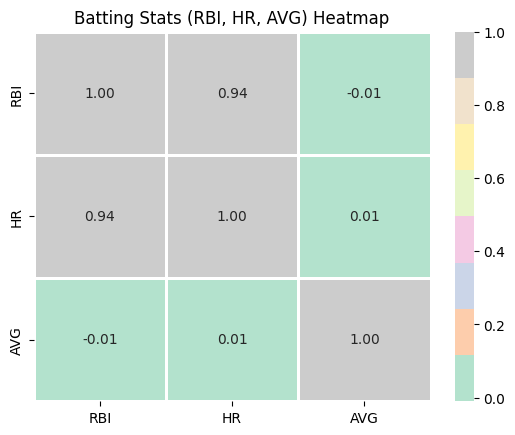

In [ ]:
# heat map of correlation between RBI, HR, and AVG
sns.heatmap(team_stats[['RBI', 'HR', 'AVG']].corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)
plt.title('Batting Stats (RBI, HR, AVG) Heatmap')
plt.show()

# Team's RBI

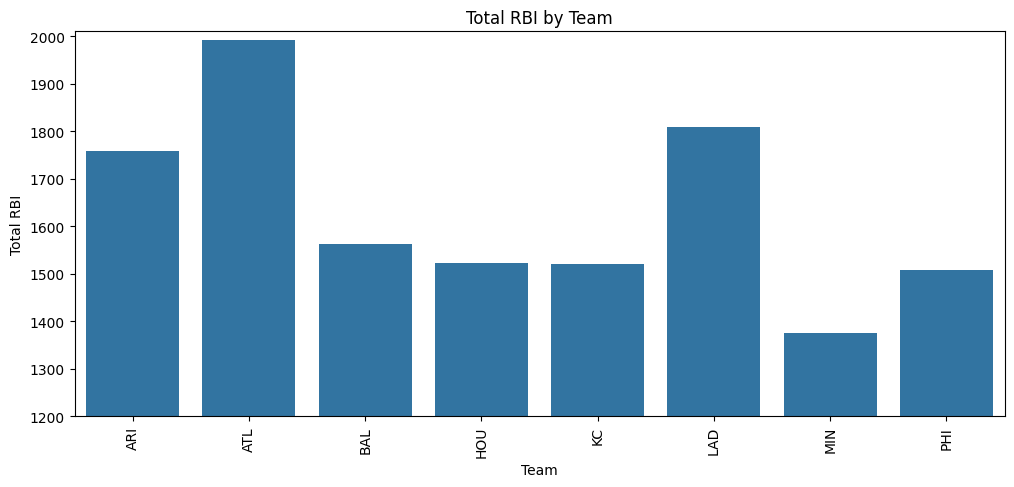

In [ ]:
# compare team's RBI and make barplot
plt.figure(figsize=(12, 5))
sns.barplot(x=team_stats.index, y=team_stats["RBI"])
plt.ylim(1200, 2010)
plt.xticks(rotation=90)
plt.xlabel("Team")
plt.ylabel("Total RBI")
plt.title("Total RBI by Team")
plt.show()

# Team's HR

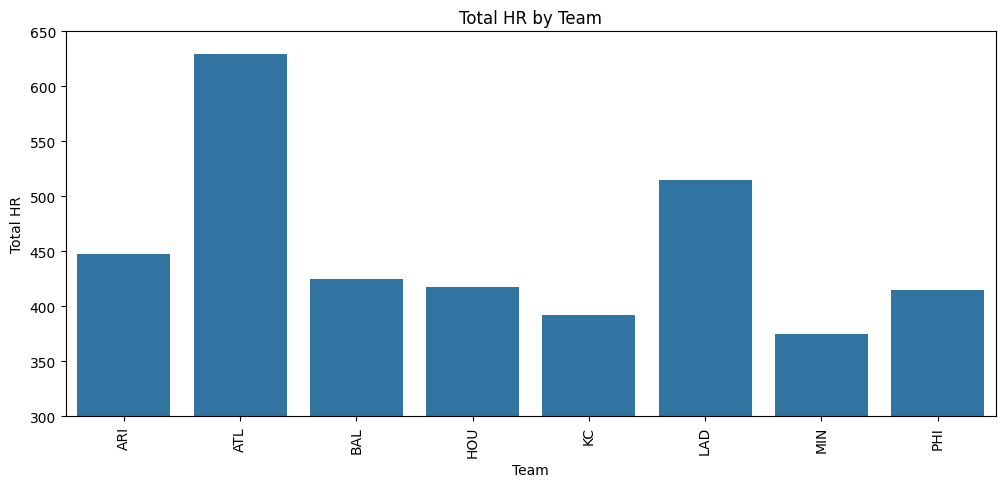

In [ ]:
# compare team's HR and make barplot
plt.figure(figsize=(12, 5))
sns.barplot(x=team_stats.index, y=team_stats["HR"])
plt.ylim(300, 650)
plt.xticks(rotation=90)
plt.xlabel("Team")
plt.ylabel("Total HR")
plt.title("Total HR by Team")
plt.show()

# Team's AVG

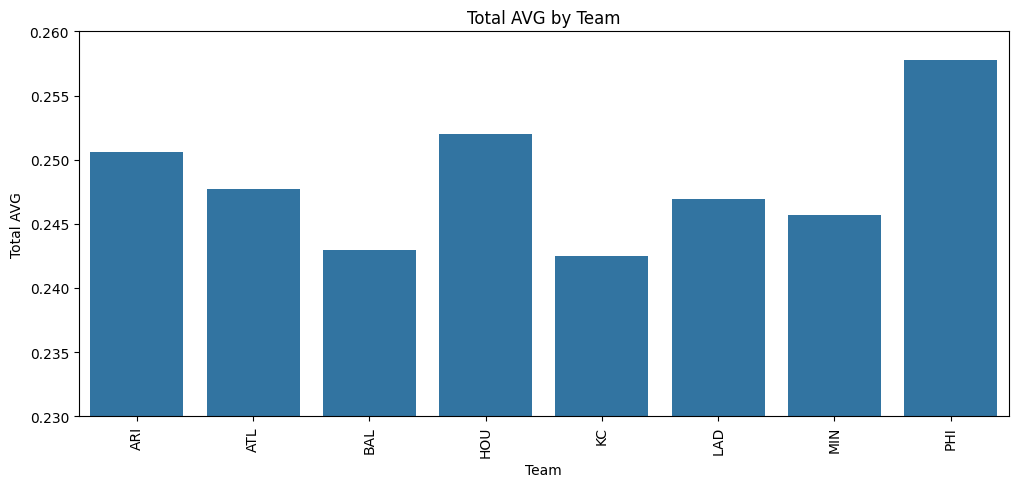

In [ ]:
# compare team's AVG and make barplot
plt.figure(figsize=(12, 5))
sns.barplot(x=team_stats.index, y=team_stats["AVG"])
plt.ylim(.23, .26)
plt.xticks(rotation=90)
plt.xlabel("Team")
plt.ylabel("Total AVG")
plt.title("Total AVG by Team")
plt.show()

# Compare Team's RBI, HR, AVG

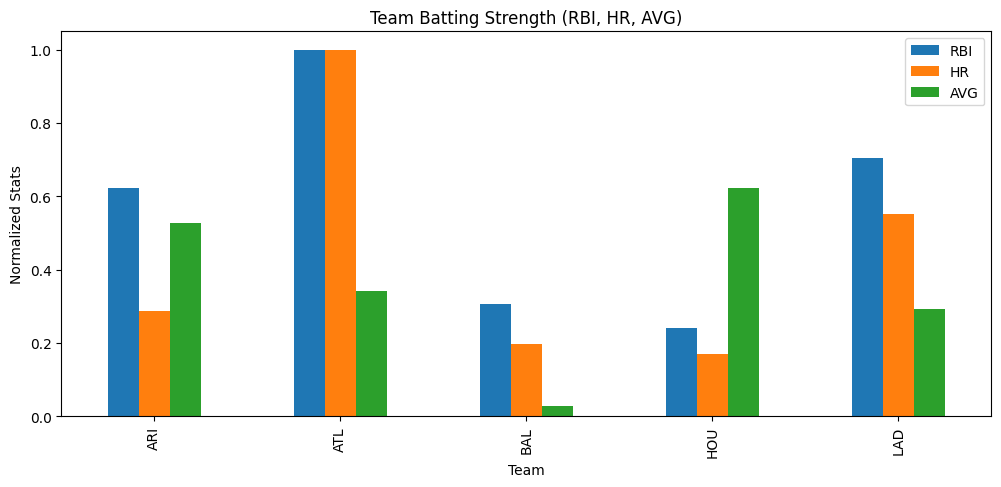

In [ ]:
# compare top 5 teams with RBI >= .24 with barplot displaying RBI, HR, AVG
# normalize stats so all values range from 0-1 and can be compared
normalized_stats = (team_stats - team_stats.min()) / (team_stats.max() - team_stats.min())

# filter stats to focus only on teams that have an RBI >= .24
filtered_stats = normalized_stats[normalized_stats["RBI"] >= 0.24]
filtered_stats.plot(kind="bar", figsize=(12, 5))
plt.title("Team Batting Strength (RBI, HR, AVG)")
plt.ylabel("Normalized Stats")
plt.xticks(rotation=90)
plt.show()